In [1]:
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Preprocess
X_train = X_train.reshape(-1, 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32') / 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Data ready.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data ready.


In [2]:
def build_model(l1=0.0, l2=0.0, dropout=0.0):
    """Create and compile an MLP with optional L1, L2, Dropout."""
    model = Sequential()
    model.add(Flatten())
    if l1 > 0:
        model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(l1)))
    elif l2 > 0:
        model.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2)))
    else:
        model.add(Dense(64, activation='relu'))
    if dropout > 0:
        model.add(Dropout(dropout))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    return model

def train_and_evaluate(model, epochs=10, batch_size=100, callbacks=None):
    """Train model, return history and test metrics."""
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_test, y_test),
                        callbacks=callbacks,
                        verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return history, loss, acc

In [3]:
# Baseline: no regularization, no dropout
baseline_model = build_model()
baseline_hist, baseline_loss, baseline_acc = train_and_evaluate(baseline_model)

print(f"Baseline  |  Test Loss: {baseline_loss:.4f}  |  Test Acc: {baseline_acc*100:.2f}%")

Baseline  |  Test Loss: 0.0875  |  Test Acc: 97.27%


In [4]:
l1_rates = [0.01, 0.001, 0.0001]
l1_results = {}
l1_histories = {}

for rate in l1_rates:
    model = build_model(l1=rate)
    hist, loss, acc = train_and_evaluate(model)
    l1_results[rate] = (loss, acc)
    l1_histories[rate] = hist
    print(f"L1 = {rate:<6} |  Loss: {loss:.4f}  |  Acc: {acc*100:.2f}%")

best_l1 = max(l1_results, key=lambda r: l1_results[r][1])
print(f"\nBest L1 rate: {best_l1}  (Acc: {l1_results[best_l1][1]*100:.2f}%)")

L1 = 0.01   |  Loss: 0.7926  |  Acc: 88.21%
L1 = 0.001  |  Loss: 0.3680  |  Acc: 94.68%
L1 = 0.0001 |  Loss: 0.1795  |  Acc: 97.01%

Best L1 rate: 0.0001  (Acc: 97.01%)


In [5]:
l2_rates = [0.01, 0.001, 0.0001]
l2_results = {}
l2_histories = {}

for rate in l2_rates:
    model = build_model(l2=rate)
    hist, loss, acc = train_and_evaluate(model)
    l2_results[rate] = (loss, acc)
    l2_histories[rate] = hist
    print(f"L2 = {rate:<6} |  Loss: {loss:.4f}  |  Acc: {acc*100:.2f}%")

best_l2 = max(l2_results, key=lambda r: l2_results[r][1])
print(f"\nBest L2 rate: {best_l2}  (Acc: {l2_results[best_l2][1]*100:.2f}%)")

L2 = 0.01   |  Loss: 0.2639  |  Acc: 95.38%
L2 = 0.001  |  Loss: 0.1603  |  Acc: 96.82%
L2 = 0.0001 |  Loss: 0.1129  |  Acc: 97.19%

Best L2 rate: 0.0001  (Acc: 97.19%)


In [6]:
dropout_rates = [0.2, 0.3, 0.5]
dropout_results = {}
dropout_histories = {}

for rate in dropout_rates:
    model = build_model(dropout=rate)
    hist, loss, acc = train_and_evaluate(model)
    dropout_results[rate] = (loss, acc)
    dropout_histories[rate] = hist
    print(f"Dropout = {rate:<4} |  Loss: {loss:.4f}  |  Acc: {acc*100:.2f}%")

best_dropout = max(dropout_results, key=lambda r: dropout_results[r][1])
print(f"\nBest Dropout rate: {best_dropout}  (Acc: {dropout_results[best_dropout][1]*100:.2f}%)")

Dropout = 0.2  |  Loss: 0.0845  |  Acc: 97.42%
Dropout = 0.3  |  Loss: 0.0940  |  Acc: 97.11%
Dropout = 0.5  |  Loss: 0.1278  |  Acc: 96.41%

Best Dropout rate: 0.2  (Acc: 97.42%)


In [7]:
patience_values = [2, 3, 5]
es_results = {}
es_histories = {}
es_stop_epoch = {}

for p in patience_values:
    model = build_model()
    early_stop = EarlyStopping(monitor='val_loss', patience=p, restore_best_weights=True)
    hist, loss, acc = train_and_evaluate(model, epochs=20, callbacks=[early_stop])
    es_results[p] = (loss, acc)
    es_histories[p] = hist
    es_stop_epoch[p] = len(hist.history['loss'])
    print(f"Patience = {p}  |  Stopped at epoch {es_stop_epoch[p]:2d}  |  Loss: {loss:.4f}  |  Acc: {acc*100:.2f}%")

best_patience = max(es_results, key=lambda p: es_results[p][1])
print(f"\nBest patience: {best_patience}  (Acc: {es_results[best_patience][1]*100:.2f}%)")

Patience = 2  |  Stopped at epoch 14  |  Loss: 0.0835  |  Acc: 97.32%
Patience = 3  |  Stopped at epoch 20  |  Loss: 0.0755  |  Acc: 97.81%
Patience = 5  |  Stopped at epoch 18  |  Loss: 0.0842  |  Acc: 97.58%

Best patience: 3  (Acc: 97.81%)


In [8]:
combined_model = build_model(l1=best_l1, dropout=best_dropout)
combined_hist, combined_loss, combined_acc = train_and_evaluate(combined_model)

print(f"Combined (L1={best_l1}, Dropout={best_dropout})")
print(f"  Test Loss: {combined_loss:.4f}  |  Test Acc: {combined_acc*100:.2f}%")

Combined (L1=0.0001, Dropout=0.2)
  Test Loss: 0.1896  |  Test Acc: 97.05%


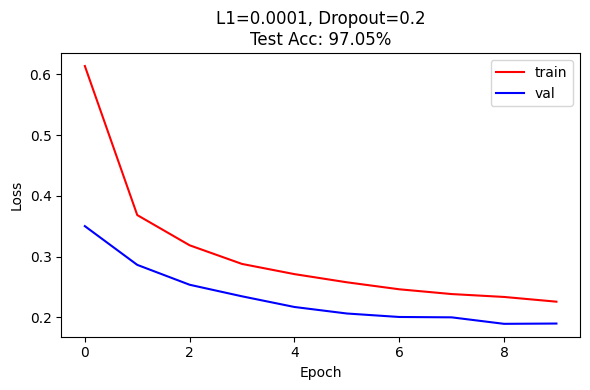

In [9]:
# Combined (L1 + Dropout) loss chart
plt.figure(figsize=(6, 4))
plt.plot(combined_hist.history['loss'], 'r', label='train')
plt.plot(combined_hist.history['val_loss'], 'b', label='val')
plt.title(f"L1={best_l1}, Dropout={best_dropout}\nTest Acc: {combined_acc*100:.2f}%")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

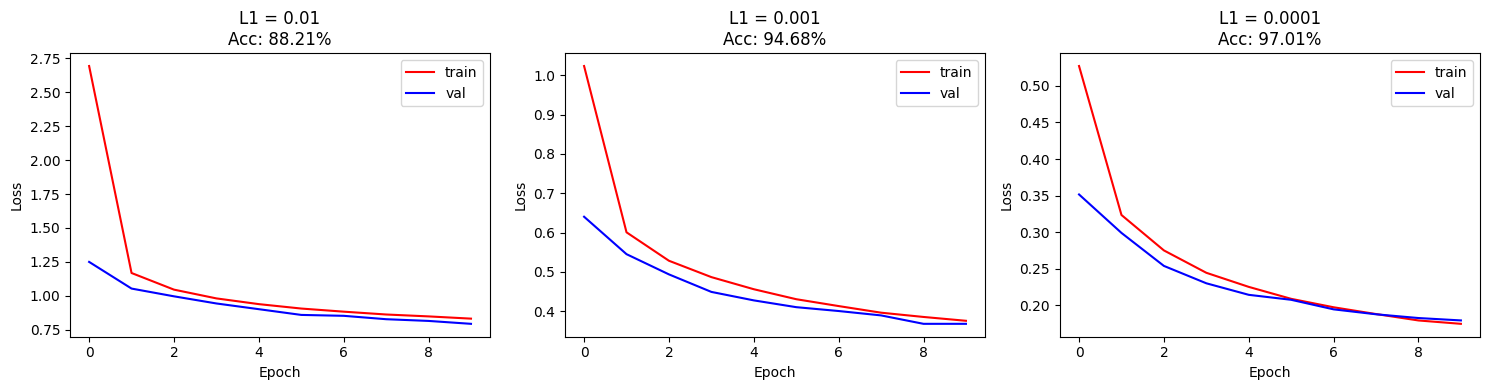

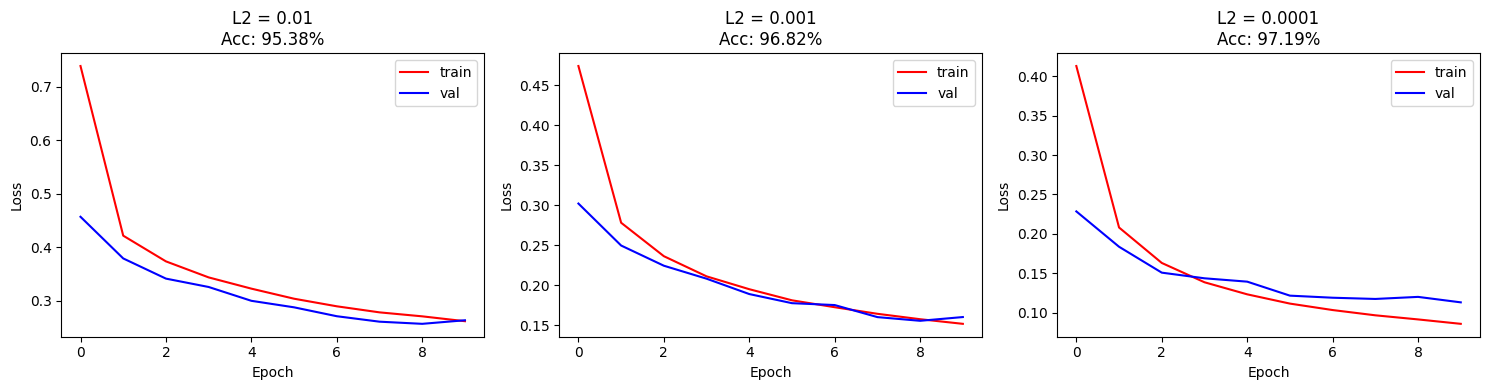

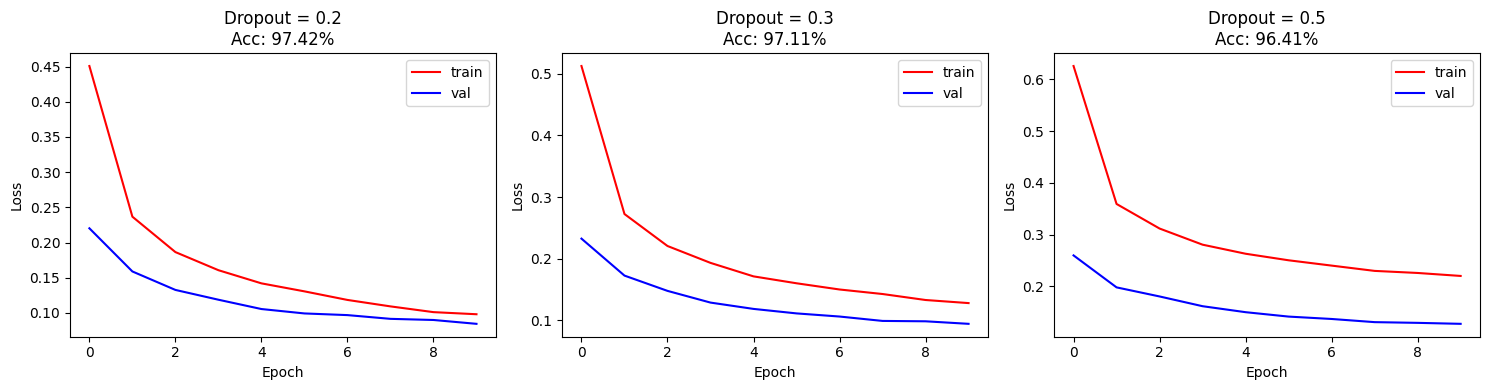

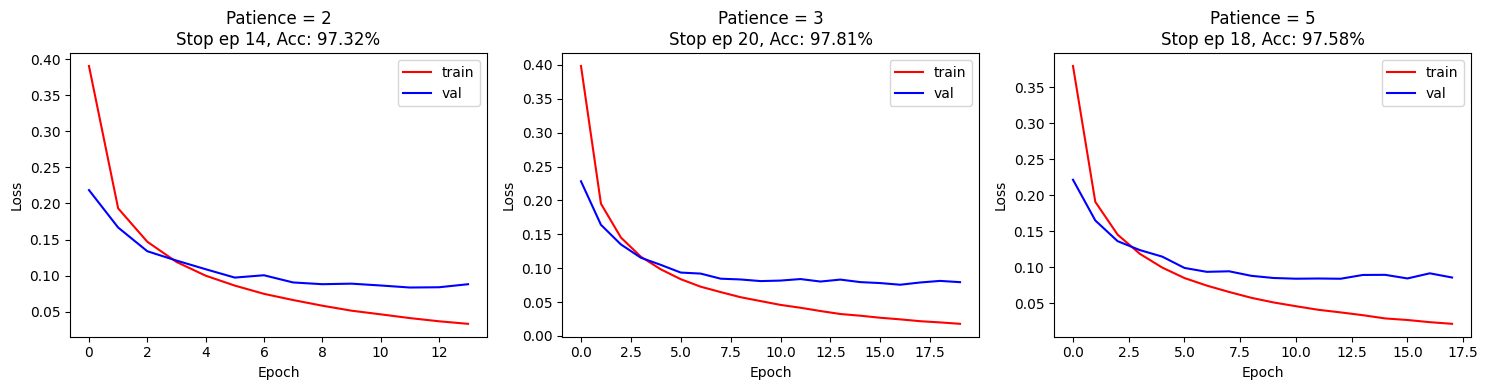

In [10]:
# L1 loss charts
fig, axes = plt.subplots(1, len(l1_rates), figsize=(15, 4))
for ax, rate in zip(axes, l1_rates):
    h = l1_histories[rate]
    ax.plot(h.history['loss'], 'r', label='train')
    ax.plot(h.history['val_loss'], 'b', label='val')
    ax.set_title(f"L1 = {rate}\nAcc: {l1_results[rate][1]*100:.2f}%")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

# L2 loss charts
fig, axes = plt.subplots(1, len(l2_rates), figsize=(15, 4))
for ax, rate in zip(axes, l2_rates):
    h = l2_histories[rate]
    ax.plot(h.history['loss'], 'r', label='train')
    ax.plot(h.history['val_loss'], 'b', label='val')
    ax.set_title(f"L2 = {rate}\nAcc: {l2_results[rate][1]*100:.2f}%")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

# Dropout loss charts
fig, axes = plt.subplots(1, len(dropout_rates), figsize=(15, 4))
for ax, rate in zip(axes, dropout_rates):
    h = dropout_histories[rate]
    ax.plot(h.history['loss'], 'r', label='train')
    ax.plot(h.history['val_loss'], 'b', label='val')
    ax.set_title(f"Dropout = {rate}\nAcc: {dropout_results[rate][1]*100:.2f}%")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

# Early Stopping loss charts
fig, axes = plt.subplots(1, len(patience_values), figsize=(15, 4))
for ax, p in zip(axes, patience_values):
    h = es_histories[p]
    ax.plot(h.history['loss'], 'r', label='train')
    ax.plot(h.history['val_loss'], 'b', label='val')
    ax.set_title(f"Patience = {p}\nStop ep {es_stop_epoch[p]}, Acc: {es_results[p][1]*100:.2f}%")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()

In [11]:
# L1 table
df_l1 = pd.DataFrame([
    {"L1 Rate": r, "Test Loss": f"{l1_results[r][0]:.4f}", "Test Acc (%)": f"{l1_results[r][1]*100:.2f}%"}
    for r in l1_rates
])
print("L1 Regularization Results")
display(df_l1)

# L2 table
df_l2 = pd.DataFrame([
    {"L2 Rate": r, "Test Loss": f"{l2_results[r][0]:.4f}", "Test Acc (%)": f"{l2_results[r][1]*100:.2f}%"}
    for r in l2_rates
])
print("\nL2 Regularization Results")
display(df_l2)

# Dropout table
df_dropout = pd.DataFrame([
    {"Dropout Rate": r, "Test Loss": f"{dropout_results[r][0]:.4f}", "Test Acc (%)": f"{dropout_results[r][1]*100:.2f}%"}
    for r in dropout_rates
])
print("\nDropout Results")
display(df_dropout)

# Early Stopping table
df_es = pd.DataFrame([
    {"Patience": p, "Stop Epoch": es_stop_epoch[p], "Test Loss": f"{es_results[p][0]:.4f}", "Test Acc (%)": f"{es_results[p][1]*100:.2f}%"}
    for p in patience_values
])
print("\nEarly Stopping Results")
display(df_es)

L1 Regularization Results


,L1 Rate,Test Loss,Test Acc (%)
0,0.0100,0.7926,88.21%
1,0.0010,0.3680,94.68%
2,0.0001,0.1795,97.01%



L2 Regularization Results


,L2 Rate,Test Loss,Test Acc (%)
0,0.0100,0.2639,95.38%
1,0.0010,0.1603,96.82%
2,0.0001,0.1129,97.19%



Dropout Results


,Dropout Rate,Test Loss,Test Acc (%)
0,0.2,0.0845,97.42%
1,0.3,0.0940,97.11%
2,0.5,0.1278,96.41%



Early Stopping Results


,Patience,Stop Epoch,Test Loss,Test Acc (%)
0,2,14,0.0835,97.32%
1,3,20,0.0755,97.81%
2,5,18,0.0842,97.58%


In [12]:
summary = pd.DataFrame([
    {"Model": "Baseline", "Config": "No regularization", "Test Loss": f"{baseline_loss:.4f}", "Test Acc (%)": f"{baseline_acc*100:.2f}%"},
    {"Model": "Best L1", "Config": f"L1 = {best_l1}", "Test Loss": f"{l1_results[best_l1][0]:.4f}", "Test Acc (%)": f"{l1_results[best_l1][1]*100:.2f}%"},
    {"Model": "Best L2", "Config": f"L2 = {best_l2}", "Test Loss": f"{l2_results[best_l2][0]:.4f}", "Test Acc (%)": f"{l2_results[best_l2][1]*100:.2f}%"},
    {"Model": "Best Dropout", "Config": f"Dropout = {best_dropout}", "Test Loss": f"{dropout_results[best_dropout][0]:.4f}", "Test Acc (%)": f"{dropout_results[best_dropout][1]*100:.2f}%"},
    {"Model": "Best Early Stop", "Config": f"Patience = {best_patience}", "Test Loss": f"{es_results[best_patience][0]:.4f}", "Test Acc (%)": f"{es_results[best_patience][1]*100:.2f}%"},
    {"Model": "Combined", "Config": f"L1={best_l1}, Dropout={best_dropout}", "Test Loss": f"{combined_loss:.4f}", "Test Acc (%)": f"{combined_acc*100:.2f}%"}
])

print("Final Summary – Best Models")
display(summary)

Final Summary – Best Models


,Model,Config,Test Loss,Test Acc (%)
0,Baseline,No regularization,0.0875,97.27%
1,Best L1,L1 = 0.0001,0.1795,97.01%
2,Best L2,L2 = 0.0001,0.1129,97.19%
3,Best Dropout,Dropout = 0.2,0.0845,97.42%
4,Best Early Stop,Patience = 3,0.0755,97.81%
5,Combined,"L1=0.0001, Dropout=0.2",0.1896,97.05%
